In [1]:
import meta
import load

In [2]:
dataset = meta.datasets[0]
records = load.load_dataset(dataset)

 11%|█         | 5/45 [00:00<00:02, 15.62it/s]

Error processing record 102-0: [Errno 2] No such file or directory: 'c:/Users/wuyan/Projects/wfdb-python/mitdb/102-0.hea'


100%|██████████| 45/45 [00:03<00:00, 14.91it/s]

Loaded 44 records from mitdb dataset.


### Check all Annotations

In [3]:
# loop through all records, counts the number of AFib/AFlutter/Others in df_ann
annotations = []
for record in records:
    df_ann = record['df_ann']
    annotations.extend(df_ann['AuxNote'].tolist())

from collections import Counter
counter = Counter(annotations)
print(counter)

Counter({'(N': 506, 'MISSB': 428, '(B': 212, '(PREX': 103, '(T': 83, '(AFIB': 83, '(VT': 60, '(AFL': 45, '(NOD': 36, '(SVTA': 26, '(VFL': 6, 'TS': 6, '(BII': 5, '(IVR': 4, 'PSE': 3, '(AB': 3, '(SBR': 1})


## Preprocess Data

In [ ]:
from preprocess import bandpass_filtering, frequency_resampling, merge_annotation_to_wave, cut_by_moving_window, populate_label, preprocess_records, generate_inputs_from_samples, generate_samples_from_records
import numpy as np

In [33]:
records = preprocess_records(records, frequency_resample=True, bandpass_filter=True)

window_duration = 20 # seconds
stride_duration = 20 # seconds
samples = generate_samples_from_records(records, window_duration=window_duration, stride_duration=stride_duration)

X_data, Y_data = generate_inputs_from_samples(samples)
X, Y = X_data.copy(), Y_data.copy()

100%|██████████| 3960/3960 [00:01<00:00, 3317.92it/s]


X shape: (3960, 4000) y shape: (3960, 20)


## Sanity Check (X, Y)

In [7]:
# map Y matrix (n_sample, n_seconds) to majority label vecotr (n_sample,)
def get_majority_label(Y):
    Y_majority = []
    for i in range(len(Y)):
        Y_majority.append(np.bincount(Y[i]).argmax())
    return np.array(Y_majority)


# count the number of occurrences of each label
counter = Counter(Y.reshape(-1))
print("Total label in Y counted as", counter)

Y_majority = get_majority_label(Y)
print("Majority label in Y counted as", Counter(Y_majority))

Total label in Y counted as Counter({0: 70752, 1: 7676, 2: 772})
Majority label in Y counted as Counter({0: 3539, 1: 386, 2: 35})


## Prepare for Training

In [32]:
np.unique(Y)

array([0., 1.])

In [31]:
from preprocess import class_to_onehot, onehot_to_class
print("Y shape:", Y.shape)
Y = class_to_onehot(Y, num_classes=3)
print("Y shape:", Y.shape)

Y shape: (3960, 60)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [9]:
# split the X,y data into train and test sets using stratified sampling on Y
from sklearn.model_selection import train_test_split
SEED = 42
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y_majority, random_state=SEED) # stratified sampling on Y_majority

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(Y_majority), y=Y_majority)))  
class_weights = {k: v / sum(class_weights.values()) for k, v in class_weights.items()} # normalize the weights to sum to 1
print("Class Weights:", class_weights)

Class Weights: {0: 0.37298671941226336, 1: 3.4196891191709846, 2: 37.714285714285715}


In [11]:
from tensorflow.keras.layers import Input, Dense, Conv1D, GlobalAveragePooling1D, Dropout, BatchNormalization, ReLU
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def network(X_train, y_train, X_test, y_test,
             unit_size, class_size, class_weights,
             learning_rate=0.001, batch_size = 32, epochs=40, 
             loss_type='cross_entropy', modelCheckPoint=False):    
    ####################################################################
    output_size = unit_size * class_size  # output size is the number of classes times the number of units
    print("Class Weights:", class_weights)
    
    def custom_loss(y_true, y_pred):
        if class_size != len(class_weights):
            raise ValueError("The length of class_weights must match the number of classes.")
        
        # Reshape tensors
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])

        loss = 0.0
        if loss_type == 'cross_entropy':
            for i in range(len(class_weights)):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        -y_true[:, :, i] * tf.math.log(y_pred[:, :, i] + 1e-15) # average loss across all samples and units
                    )
        elif loss_type == 'mse':
            for i in range(len(class_weights)):
                if class_weights[i] > 0:
                    loss += class_weights[i] * tf.reduce_mean(
                        tf.square(y_true[:, :, i] - y_pred[:, :, i])  # average loss across all samples and units
                    )
        else:
            raise ValueError("Invalid loss type. Use 'cross_entropy' or 'mse'.")
        return loss

    def custom_accuracy(y_true, y_pred):
        y_true = tf.reshape(y_true, [-1, unit_size, class_size])
        y_pred = tf.reshape(y_pred, [-1, unit_size, class_size])
        correct_predictions = tf.equal(tf.argmax(y_true, axis=2), tf.argmax(y_pred, axis=2))
        return tf.reduce_mean(tf.cast(correct_predictions, tf.float32)) # average accuracy across all samples and units

    ####################################################################
    inputs_cnn = Input(shape=(X_train.shape[1], 1))

    # Block 1
    x = Conv1D(16, kernel_size=7, padding='same')(inputs_cnn)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Block 2
    x = Conv1D(32, kernel_size=5, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(32, kernel_size=3, padding='same')(x)

    # Block 3
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(64, kernel_size=3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(64, kernel_size=3, padding='same')(x)

    # Final block
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = GlobalAveragePooling1D()(x)

    # Output layer
    outputs_cnn = Dense(output_size, activation='softmax')(x)

    optimizer = Adam(learning_rate=learning_rate)
    model = Model(inputs=inputs_cnn, outputs=outputs_cnn)
    model.compile(optimizer=optimizer, loss=custom_loss, metrics=[custom_accuracy])

    # define callbacks for early stopping and saving the best model with lowest validation loss
    callbacks = [EarlyStopping(monitor='val_loss', patience=8)]
    if modelCheckPoint:
        callbacks.append(ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True))
    history=model.fit(X_train, y_train, epochs=epochs, 
                      callbacks=callbacks, batch_size=batch_size, validation_data=(X_test, y_test),
                      #class_weight=class_weights # assign class weights to the model 
                      ) 
    if modelCheckPoint:
        model.load_weights('best_model.h5')
    return (model, history)

In [12]:
model, history=network(X_train, Y_train, X_test, Y_test,
                      unit_size=window_duration, class_size=3, class_weights=class_weights,
                      learning_rate=0.0001, batch_size=32, epochs=10, loss_type='cross_entropy', modelCheckPoint=False)

Class Weights: {0: 0.00898612438631954, 1: 0.0823883269512561, 2: 0.9086255486624243}
Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - custom_accuracy: 0.2423 - loss: 0.1036 - val_custom_accuracy: 0.4716 - val_loss: 0.1020
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 308ms/step - custom_accuracy: 0.2564 - loss: 0.0888 - val_custom_accuracy: 0.2773 - val_loss: 0.1019
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 34s 340ms/step - custom_accuracy: 0.2345 - loss: 0.1133 - val_custom_accuracy: 0.2096 - val_loss: 0.1014
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 285ms/step - custom_accuracy: 0.2321 - loss: 0.0914 - val_custom_accuracy: 0.2531 - val_loss: 0.1003
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - custom_accuracy: 0.2051 - loss: 0.0978 - val_custom_accuracy: 0.2535 - val_loss: 0.0990
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - custom_accuracy: 0.2033 - loss: 0.1005 - val_custom_accuracy: 0.3526 - val_loss: 0.0971
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - c

### Error Analysis

In [18]:
from analysis import plot_accuracy_and_loss, plot_confusion_matrix
from sklearn.metrics import confusion_matrix

Accuracy: 54.58%


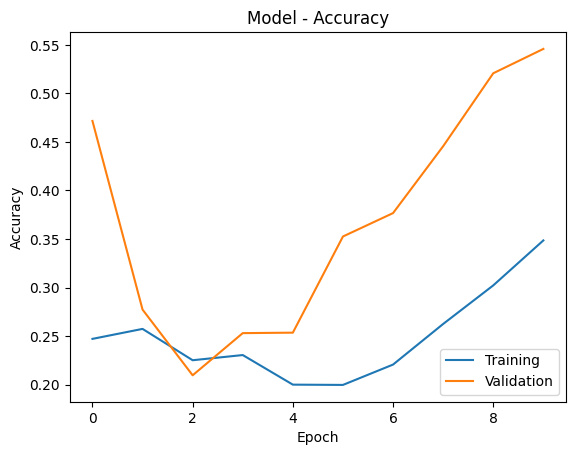

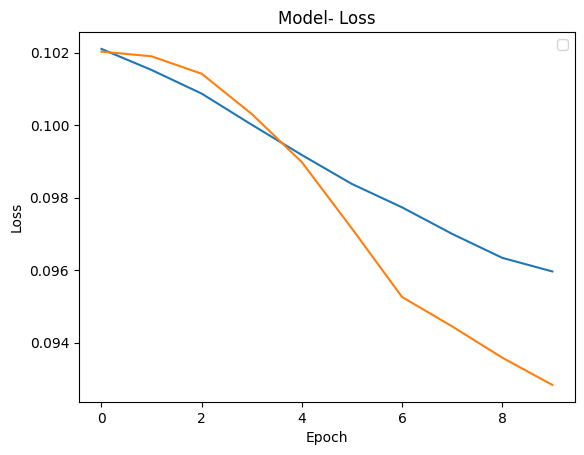

In [ ]:
plot_accuracy_and_loss(history, X_test, Y_test, model)

In [21]:
Y_pred_onehot = model.predict(X_test)
Y_pred_class = onehot_to_class(Y_pred_onehot, num_classes=3)
Y_test_onehot = Y_test.copy()
Y_test_class = onehot_to_class(Y_test_onehot, num_classes=3)

# calculate the accuracy for each class
for i in range(3):
    acc = np.sum((Y_test_class == i) & (Y_pred_class == i)) / np.sum(Y_test_class == i)
    print(f"Accuracy for class {i}: {acc:.2f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Accuracy for class 0: 0.50
Accuracy for class 1: 0.92
Accuracy for class 2: 0.99


In [27]:
# calculate the confusion matrix based on Y_test_class and Y_pred_class
C = np.zeros((3, 3))
for i in range(len(Y_test_class)):
    for j in range(len(Y_test_class[i])):
        C[int(Y_test_class[i][j]), int(Y_pred_class[i][j])] += 1
print("Confusion Matrix:")
print(C)

Confusion Matrix:
[[7.067e+03 3.814e+03 3.267e+03]
 [1.900e+01 1.411e+03 1.070e+02]
 [1.000e+00 0.000e+00 1.540e+02]]


In [17]:
y_pred=model.predict(X_test)
cnf_matrix = confusion_matrix(Y_test, y_pred.argmax(axis=1))
plot_confusion_matrix(cnf_matrix, classes=['N', 'AFib', 'AFlu'], normalize=True)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets